Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1-Score  : 0.5455

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Model Intercept (beta_0): -0.8721553689217155

Learned Weights (beta_i):
 Glucose             1.182511
BMI                 0.688735
Pregnancies         0.377502
DiabetesPedigree    0.233386
Age                 0.147798
SkinThickness       0.028225
BloodPressure      -0.044066
Insulin            -0.066157
dtype: float64


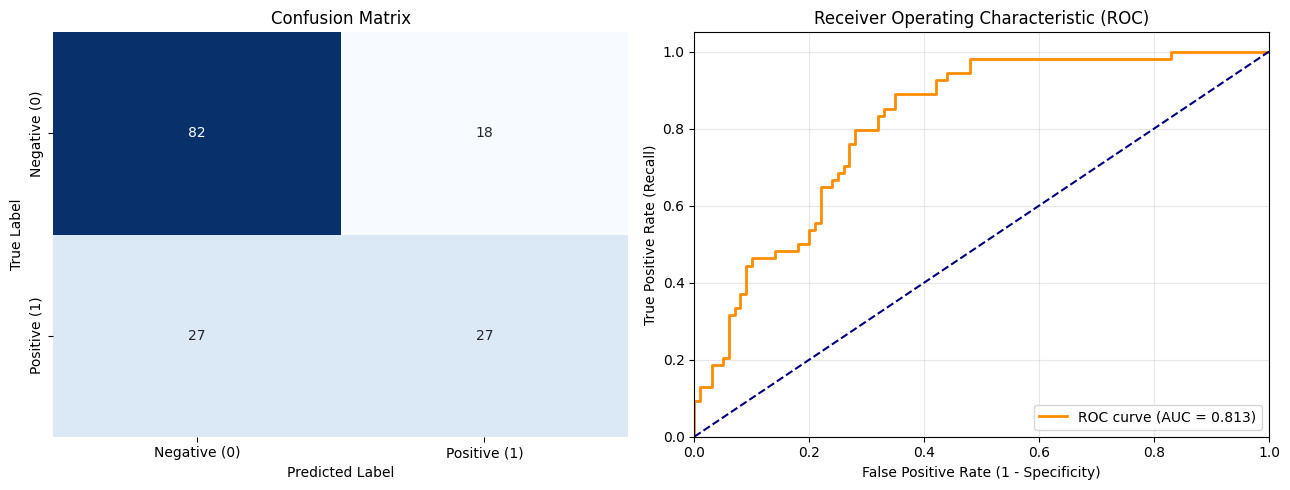

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ---------------------------------------------------------
# 1. Load Real-World Dataset (Pima Indians Diabetes)
# ---------------------------------------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome"
]

df = pd.read_csv(url, names=columns)

# Handle biological zeroes in clinical measurements by replacing with median
zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_features] = df[zero_features].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

# ---------------------------------------------------------
# 2. Features and Target Split
# ---------------------------------------------------------
X = df.drop(columns=["Outcome"])  # 8 input columns
y = df["Outcome"]                  # 1 target column

# ---------------------------------------------------------
# 3. Train-Test Split (80/20, random_state=42)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 4. Feature Standardization
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 5. Model Training
# ---------------------------------------------------------
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 6. Evaluation & Predictions
# ---------------------------------------------------------
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metric calculations
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 45)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Display Learned Logistic Equation Parameters
print("Model Intercept (beta_0):", model.intercept_[0])
feature_weights = pd.Series(model.coef_[0], index=X.columns)
print("\nLearned Weights (beta_i):\n", feature_weights.sort_values(ascending=False))

# ---------------------------------------------------------
# 7. Visualizations: Confusion Matrix & ROC Curve
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("Receiver Operating Characteristic (ROC)")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()